In [1]:
import pandas as pd
import numpy as np

In [2]:
# Facebook
fb = pd.read_csv("Data/Facebook/WHE_FB_ Jan-01-2025_Dec-31-2025_1019453797917611.csv")

# Instagram
ig = pd.read_csv("Data/Instagram/WHE_IG_Jan-01-2025_Dec-31-2025_1425271635386019.csv")

# YouTube
yt_table = pd.read_csv("Data/YouTube/Table data.csv")
yt_chart = pd.read_csv("Data/YouTube/Chart data.csv")
yt_total = pd.read_csv("Data/YouTube/Totals.csv")

# Google Analytics
ga_page = pd.read_csv("Data/Google Analytics/Basic data/Basic 2023-2026page_view.csv", skiprows=8)
ga_new_return = pd.read_csv("Data/Google Analytics/Basic data/New_vs_Returning_Users.csv", skiprows=9)
ga_events = pd.read_csv("Data/Google Analytics/Basic data/Simple Events by event name 2023-2026.csv", skiprows=9)
ga_acquisition = pd.read_csv("Data/Google Analytics/Basic data/User_acquisition_First_user_primary_channel_group_(Default_channel_group).csv", skiprows=9)

ga_age_visit = pd.read_csv("Data/Google Analytics/By Age Range/Visit vs ages.csv",skiprows=9)
ga_age_eng = pd.read_csv("Data/Google Analytics/By Age Range/User Engagement vs ages.csv",skiprows=9)
ga_age_download = pd.read_csv("Data/Google Analytics/By Age Range/Download vs Ages.csv",skiprows=9)

ga_platform_visit = pd.read_csv("Data/Google Analytics/By Platform/Visit vs platform.csv",skiprows=9)
ga_platform_eng = pd.read_csv("Data/Google Analytics/By Platform/User engagement vs platform.csv",skiprows=9)
ga_platform_download = pd.read_csv("Data/Google Analytics/By Platform/Download vs platform.csv",skiprows=9)

ga_country_visit = pd.read_csv("Data/Google Analytics/Event vs countries/Website visit_Countries.csv",skiprows=9)
ga_country_eng = pd.read_csv("Data/Google Analytics/Event vs countries/User Engagement vs countries.csv",skiprows=9)
ga_country_download = pd.read_csv("Data/Google Analytics/Event vs countries/Download vs countries.csv",skiprows=9)

The LinkedIn datasets contain multiple sheets representing different types of information such as content performance, follower demographics, and visitor analytics.
For this analysis, only the relevant sheets are selected to align with the research questions:
- Content-related sheets (e.g., All posts, Metrics) are used for engagement analysis (RQ1)
- Follower and visitor sheets (e.g., New followers, Location, Visitor metrics) are used for audience and platform analysis (RQ2)

In [3]:
import sys
!{sys.executable} -m pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\anush\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
base_path = "Data/LinkedIn/"
# Content
ln_content_metrics = pd.read_excel(base_path+"Linkedin Content waste-hero-education_content_1772771793256.xls",sheet_name="Metrics")
ln_content_posts = pd.read_excel(base_path+"Linkedin Content waste-hero-education_content_1772771793256.xls",sheet_name="All posts", skiprows=1)

In [5]:
ln_content_posts.head()

,Post title,Post link,Post type,Campaign name,Posted by,Created date,Campaign start date,Campaign end date,Audience,Impressions,Views,Offsite Views,Clicks,Click through rate (CTR),Likes,Comments,Reposts,Follows,Engagement rate,Content Type
0,Empowering Educators is back! Join us as we ex...,https://www.linkedin.com/feed/update/urn:li:ac...,Organic,NaN,Gamm Ritthinumporn,02/25/2026,NaN,NaN,All followers,162,NaN,NaN,3,0.018519,0,0,0,NaN,0.018519,NaN
1,🌍 Meet Naifa Zaman – A Young Change-Maker from...,https://www.linkedin.com/feed/update/urn:li:ac...,Organic,NaN,Gamm Ritthinumporn,02/19/2026,NaN,NaN,All followers,27,NaN,NaN,0,0.000000,5,0,0,NaN,0.185185,NaN
2,♻️ Do You Know How Recycling Works Around the ...,https://www.linkedin.com/feed/update/urn:li:ac...,Organic,NaN,Gamm Ritthinumporn,02/11/2026,NaN,NaN,All followers,67,33.0,NaN,3,0.044776,3,0,1,NaN,0.104478,Video
3,🌱 Turn Your New Year’s Resolution into Real Im...,https://www.linkedin.com/feed/update/urn:li:ac...,Organic,NaN,Gamm Ritthinumporn,02/06/2026,NaN,NaN,All followers,63,NaN,NaN,0,0.000000,2,0,1,NaN,0.047619,NaN
4,🔊 Hello Educators!\n\nWaste Hero Education is ...,https://www.linkedin.com/feed/update/urn:li:ac...,Organic,NaN,Gamm Ritthinumporn,02/04/2026,NaN,NaN,All followers,8,NaN,NaN,0,0.000000,0,0,0,NaN,0.000000,NaN


### Data Cleaning

**Standardize column names**

In [6]:
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

fb = clean_columns(fb)
ig = clean_columns(ig)
ln_content_posts = clean_columns(ln_content_posts)
yt_table = clean_columns(yt_table)

**Convert date fields** to datetime format for time-based analysis.

In [7]:
fb['publish_time'] = pd.to_datetime(fb['publish_time'], errors='coerce')
ig['publish_time'] = pd.to_datetime(ig['publish_time'], errors='coerce')
ln_content_posts['created_date'] = pd.to_datetime(ln_content_posts['created_date'], errors='coerce')

**Remove Empty / Irrelevant Rows**

In [8]:
fb = fb.dropna(how='all')
ig = ig.dropna(how='all')
ln_content_posts = ln_content_posts.dropna(how='all')

In [9]:
print(len(fb.columns))

174


Remove columns that contain only missing values to reduce noise and improve efficiency.

In [10]:
fb = fb.dropna(axis=1, how='all')
print(len(fb.columns))

170


**Handle Missing Values** - Fill missing values for numerical consistency.

In [11]:
fb = fb.fillna(0)
ig = ig.fillna(0)
ln_content_posts = ln_content_posts.fillna(0)

### Feature Engineering

##### Create Engagement Metrics
**Facebook Features** - Engineer engagement, CTR, and organic vs boosted performance features for Facebook posts.

In [12]:
fb_fe = fb[['publish_time', 'post_type', 'title', 'description',
    'views', 'reach','reactions,_comments_and_shares',  # already combined engagement
    'reactions', 'comments', 'shares','total_clicks',
    'views_from_organic_posts', 'views_from_boosted_posts','reach_from_organic_posts', 'reach_from_boosted_posts']].copy()

In [13]:
fb_fe = fb_fe.rename(columns={'reactions,_comments_and_shares': 'engagement',
                             'publish_time': 'date'})

In [14]:
# Engagement rate
fb_fe['engagement_rate'] = fb_fe['engagement'] / fb_fe['reach'].replace(0, np.nan)

# Click-through rate
fb_fe['ctr'] = fb_fe['total_clicks'] / fb_fe['reach'].replace(0, np.nan)

# Organic vs Boosted ratio
fb_fe['organic_ratio'] = fb_fe['reach_from_organic_posts'] / (fb_fe['reach_from_organic_posts'] + fb_fe['reach_from_boosted_posts']).replace(0, np.nan)

# Content text (for NLP later)
fb_fe['content'] = (fb_fe['title'].fillna('').astype(str) + " " + fb_fe['description'].fillna('').astype(str)).str.strip()

# Platform label
fb_fe['platform'] = 'facebook'

In [15]:
fb_fe.head()

,date,post_type,title,description,views,reach,engagement,reactions,comments,shares,total_clicks,views_from_organic_posts,views_from_boosted_posts,reach_from_organic_posts,reach_from_boosted_posts,engagement_rate,ctr,organic_ratio,content,platform
0,2025-01-08 11:30:00,Photos,"🔄 Rethink, reduce, reuse! From practical tips ...",0,102,59,2,2,0,0,0,102,0,59,0,0.033898,0.000000,1.0,"🔄 Rethink, reduce, reuse! From practical tips ...",facebook
1,2025-01-03 13:00:00,Photos,"🌍✨ New Year, New You! Ready to Become a Waste ...",0,377,217,9,5,0,4,0,377,0,217,0,0.041475,0.000000,1.0,"🌍✨ New Year, New You! Ready to Become a Waste ...",facebook
2,2025-12-29 06:00:00,Photos,Make your Christmas a little greener this year...,0,117,68,1,1,0,0,3,117,0,68,0,0.014706,0.044118,1.0,Make your Christmas a little greener this year...,facebook
3,2025-12-26 23:00:00,Photos,Great news for this year! 🎉💻\nOur Waste Hero: ...,0,148,86,3,3,0,0,1,148,0,86,0,0.034884,0.011628,1.0,Great news for this year! 🎉💻\nOur Waste Hero: ...,facebook
4,2025-12-24 21:00:00,Photos,"Wishing you a Merry Christmas, Happy Holiday a...",0,143,82,4,3,1,0,3,143,0,82,0,0.048780,0.036585,1.0,"Wishing you a Merry Christmas, Happy Holiday a...",facebook


**Instagram Features** - Create engagement and engagement rate metrics for Instagram posts.

In [16]:
ig_fe = ig[['publish_time', 'post_type', 'description', 'views', 'reach', 'likes', 'comments', 'shares', 'saves']].copy()

In [17]:
ig_fe = ig_fe.rename(columns={'publish_time': 'date'})
# Engagement
ig_fe['engagement'] = (ig_fe['likes'] + ig_fe['comments'] + ig_fe['shares'] + ig_fe['saves'])
# Engagement rate
ig_fe['engagement_rate'] = ig_fe['engagement'] / ig_fe['reach'].replace(0, np.nan)
# Content text
ig_fe['content'] = ig_fe['description']
# Platform
ig_fe['platform'] = 'instagram'

In [18]:
ig_fe.head()

,date,post_type,description,views,reach,likes,comments,shares,saves,engagement,engagement_rate,content,platform
0,2025-01-08 11:30:00,IG image,"🔄 Rethink, reduce, reuse! From practical tips ...",72,40,4,0,0,0,4,0.100000,"🔄 Rethink, reduce, reuse! From practical tips ...",instagram
1,2025-01-03 13:03:00,IG image,"🌍✨ New Year, New You! Ready to Become a Waste ...",94,44,1,0,0,1,2,0.045455,"🌍✨ New Year, New You! Ready to Become a Waste ...",instagram
2,2025-12-29 06:05:00,IG image,Make your Christmas a little greener this year...,80,40,2,0,0,0,2,0.050000,Make your Christmas a little greener this year...,instagram
3,2025-12-26 23:00:00,IG image,Great news for this year! 🎉💻\nOur Waste Hero: ...,186,110,5,0,2,0,7,0.063636,Great news for this year! 🎉💻\nOur Waste Hero: ...,instagram
4,2025-12-24 21:00:00,IG image,"Wishing you a Merry Christmas, Happy Holiday a...",73,38,1,0,0,0,1,0.026316,"Wishing you a Merry Christmas, Happy Holiday a...",instagram


**LinkedIn (Post-Level)** - Compute engagement and CTR for LinkedIn posts using interaction metrics.

In [19]:
ln_fe = ln_content_posts[['created_date', 'post_type', 'post_title', 'impressions', 'views', 'clicks',
    'likes', 'comments', 'reposts', 'engagement_rate']].copy()

In [20]:
# Total engagement
ln_fe['engagement'] = (ln_fe['likes'] + ln_fe['comments'] + ln_fe['reposts'])
# CTR
ln_fe['ctr'] = ln_fe['clicks'] / ln_fe['impressions'].replace(0, np.nan)
# Content text
ln_fe['content'] = ln_fe['post_title']
# Date
ln_fe = ln_fe.rename(columns={'created_date': 'date'})
# Platform
ln_fe['platform'] = 'linkedin'

In [21]:
ln_fe.head()

,date,post_type,post_title,impressions,views,clicks,likes,comments,reposts,engagement_rate,engagement,ctr,content,platform
0,2026-02-25,Organic,Empowering Educators is back! Join us as we ex...,162,0.0,3,0,0,0,0.018519,0,0.018519,Empowering Educators is back! Join us as we ex...,linkedin
1,2026-02-19,Organic,🌍 Meet Naifa Zaman – A Young Change-Maker from...,27,0.0,0,5,0,0,0.185185,5,0.000000,🌍 Meet Naifa Zaman – A Young Change-Maker from...,linkedin
2,2026-02-11,Organic,♻️ Do You Know How Recycling Works Around the ...,67,33.0,3,3,0,1,0.104478,4,0.044776,♻️ Do You Know How Recycling Works Around the ...,linkedin
3,2026-02-06,Organic,🌱 Turn Your New Year’s Resolution into Real Im...,63,0.0,0,2,0,1,0.047619,3,0.000000,🌱 Turn Your New Year’s Resolution into Real Im...,linkedin
4,2026-02-04,Organic,🔊 Hello Educators!\n\nWaste Hero Education is ...,8,0.0,0,0,0,0,0.000000,0,0.000000,🔊 Hello Educators!\n\nWaste Hero Education is ...,linkedin


**Youtube** - Use engagement proxies and retention metrics for YouTube performance analysis.

In [22]:
yt_fe = yt_table[['video_title', 'video_publish_time','views', 'engaged_views', 'average_view_duration', 'average_percentage_viewed_(%)',
    'watch_time_(hours)', 'subscribers', 'impressions','impressions_click-through_rate_(%)']].copy()

In [23]:
# Engagement proxy
yt_fe['engagement'] = yt_fe['engaged_views']
# CTR
yt_fe['ctr'] = yt_fe['impressions_click-through_rate_(%)']
# Retention score
yt_fe['retention'] = yt_fe['average_percentage_viewed_(%)']
# Content
yt_fe['content'] = yt_fe['video_title']
# Date
yt_fe = yt_fe.rename(columns={'video_publish_time': 'date'})
# Platform
yt_fe['platform'] = 'youtube'

For YouTube, engagement rate is computed as the ratio of engaged views to total views. 
This reflects how many viewers actively engaged with the content relative to total exposure, 
which differs from interaction-based engagement metrics used on other platforms.

In [24]:
yt_fe['engagement_rate'] = yt_fe['engaged_views'] / yt_fe['views']

In [25]:
yt_fe.head()

,video_title,date,views,engaged_views,average_view_duration,average_percentage_viewed_(%),watch_time_(hours),subscribers,impressions,impressions_click-through_rate_(%),engagement,ctr,retention,content,platform,engagement_rate
0,NaN,NaN,3223155,2300071,0:01:10,41.43,48029.2628,172,27329,3.66,2300071,3.66,41.43,NaN,youtube,0.713609
1,Waste Hero - Free Zero Waste Lesson Plans,24-Apr-23,1307033,1307033,0:00:45,88.28,16345.4263,108,5924,5.35,1307033,5.35,88.28,Waste Hero - Free Zero Waste Lesson Plans,youtube,1.000000
2,What is Waste Hero Education?,25-Jul-25,1432562,691690,0:00:51,62.82,12019.1067,0,279,2.87,691690,2.87,62.82,What is Waste Hero Education?,youtube,0.482834
3,Waste Hero Education : Circular Economy,7-Aug-25,390937,245410,0:04:10,24.64,17548.7970,0,2067,4.06,245410,4.06,24.64,Waste Hero Education : Circular Economy,youtube,0.627748
4,Waste Hero Education : What is recycling,7-Aug-25,41924,26583,0:02:38,36.96,1217.2046,0,931,2.36,26583,2.36,36.96,Waste Hero Education : What is recycling,youtube,0.634076


#### Descriptive Analysis

**Platform Overview** 
1. Number of Posts per Platform - Analyze the number of posts across platforms to understand content distribution.
2. Basic Stats per Platform - Compare engagement and engagement rate across platforms.

In [26]:
#1
pd.concat([fb_fe['platform'], ig_fe['platform'], ln_fe['platform']]).value_counts()

platform
facebook     119
instagram    118
linkedin      89
Name: count, dtype: int64

In [27]:
#2
combined_fe = pd.concat([fb_fe, ig_fe, ln_fe, yt_fe], ignore_index=True)
combined_fe.groupby('platform')[['engagement', 'engagement_rate']].sum()

,engagement,engagement_rate
platform,,
facebook,514,3.088249
instagram,582,7.183562
linkedin,270,7.741807
youtube,4600030,24.578649


In [28]:
combined_fe = combined_fe[combined_fe['platform'] != 'youtube']

**Engagement Distribution** - Examine engagement variability across platforms.

In [29]:
combined_fe['engagement'].describe()

count    326.000000
mean       4.190184
std        6.367757
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       51.000000
Name: engagement, dtype: float64

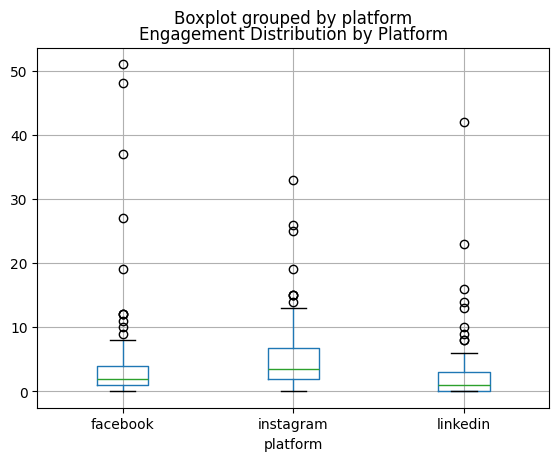

In [30]:
import matplotlib.pyplot as plt
combined_fe.boxplot(column='engagement', by='platform')
plt.title("Engagement Distribution by Platform")
plt.show()

**Engagement by Platform** - This chart compares average engagement across platforms to identify where content performs best.

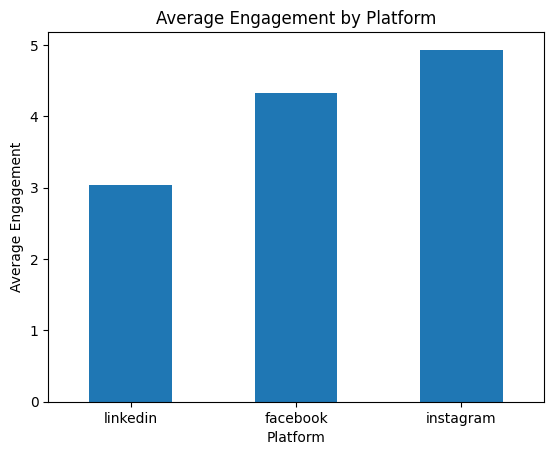

In [31]:
import matplotlib.pyplot as plt

platform_eng = combined_fe.groupby('platform')['engagement'].mean().sort_values()

platform_eng.plot(kind='bar')
plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement")
plt.xticks(rotation=0)
plt.show()

The comparison of average engagement across platforms shows that Instagram achieves the highest engagement, followed by Facebook, while LinkedIn has the lowest engagement levels. This suggests that visually driven platforms like Instagram are more effective for sustainability-related content, likely due to their ability to communicate ideas through images and short-form media. In contrast, LinkedIn’s lower engagement indicates that professional audiences may interact less frequently with such content or require a different content strategy.

**Content Type Analysis** - Compare engagement across content formats within each platform.

In [32]:
#Facebook
fb_fe.groupby('post_type')['engagement'].mean().sort_values(ascending=False)

post_type
Photos    4.477273
Videos    4.103448
Reels     1.000000
Text      0.000000
Name: engagement, dtype: float64

In [33]:
#Instagram
ig_fe.groupby('post_type')['engagement'].mean().sort_values(ascending=False)

post_type
IG reel        5.000000
IG image       4.971429
IG carousel    4.684211
Name: engagement, dtype: float64

In [34]:
#LinkedIn
ln_fe.groupby('post_type')['engagement'].mean().sort_values(ascending=False)

post_type
Total        20.000000
Sponsored     5.800000
Organic       2.234568
Name: engagement, dtype: float64

In [35]:
#Content Type Distribution
print("--Facebook--")
print(fb_fe['post_type'].value_counts())
print("--Instagram--")
print(ig_fe['post_type'].value_counts())
print("--LinkedIn--")
print(ln_fe['post_type'].value_counts())

--Facebook--
post_type
Photos    88
Videos    29
Text       1
Reels      1
Name: count, dtype: int64
--Instagram--
post_type
IG image       70
IG reel        29
IG carousel    19
Name: count, dtype: int64
--LinkedIn--
post_type
Organic      81
Sponsored     5
Total         3
Name: count, dtype: int64


In [36]:
#Engagement Over Time
combined_fe.groupby(['date', 'platform'])['engagement'].mean().reset_index()

,date,platform,engagement
0,2025-01-03 13:00:00,facebook,9.0
1,2025-01-03 13:03:00,instagram,2.0
2,2025-01-08 11:30:00,facebook,2.0
3,2025-01-08 11:30:00,instagram,4.0
4,2025-01-11 15:00:00,facebook,0.0
...,...,...,...
309,2026-02-04 00:00:00,linkedin,0.0
310,2026-02-06 00:00:00,linkedin,3.0
311,2026-02-11 00:00:00,linkedin,4.0
312,2026-02-19 00:00:00,linkedin,5.0


**Content Type vs Engagement** - This chart highlights how different content formats influence engagement levels.

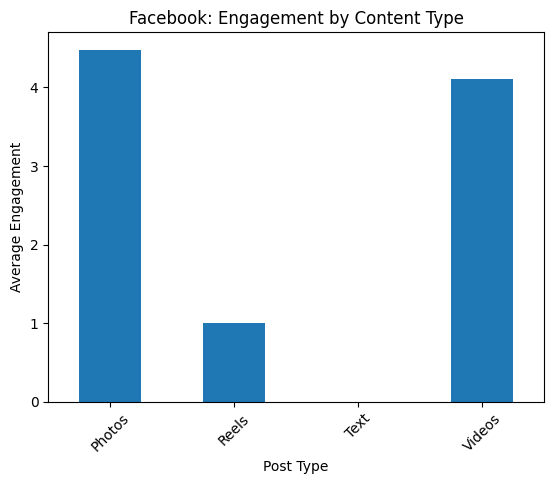

In [37]:
fb_ct = fb_fe.groupby('post_type')['engagement'].mean()

fb_ct.plot(kind='bar')
plt.title("Facebook: Engagement by Content Type")
plt.xlabel("Post Type")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.show()

Photo-based content generates the highest engagement on Facebook, followed by videos. However, reels and text posts show lower engagement, though their sample sizes are very small, limiting reliable comparison. Overall, visual formats such as photos and videos appear more effective for driving interactions.

### RQ1

**How do content themes and delivery formats (for example: recycling, zero waste, circular economy, education, youth action; and photo, video, reel, carousel, text post) jointly influence engagement efficiency across different social media platforms?**

Sub-question: **Are certain sustainability themes consistently high-performing across platforms, or are they platform-specific?**

What we are trying to find - We want to identify which combinations of theme + format + platform lead to stronger engagement, and whether some themes perform consistently across platforms or vary depending on the platform.

Approach - We will combine all platform data, standardize content formats, and then analyze engagement across themes and formats, followed by cross-platform comparisons.

**Build one RQ1 Dataset** - Create one combined dataset for RQ1 by bringing together platform, content text, content format, and engagement variables from all social media sources.

In [38]:
# Facebook
fb_rq1 = fb_fe[['date', 'platform', 'post_type', 'content', 'engagement', 'engagement_rate']].copy()
# Instagram
ig_rq1 = ig_fe[['date', 'platform', 'post_type', 'content', 'engagement', 'engagement_rate']].copy()
# LinkedIn
ln_rq1 = ln_fe[['date', 'platform', 'post_type', 'content', 'engagement', 'engagement_rate']].copy()
# YouTube
yt_rq1 = yt_fe[['date', 'platform', 'content', 'engagement','engagement_rate']].copy()
yt_rq1['post_type'] = 'video'
# Combine
rq1_df = pd.concat([fb_rq1, ig_rq1, ln_rq1, yt_rq1], ignore_index=True)

# Basic text cleanup
rq1_df['content'] = rq1_df['content'].fillna('').astype(str).str.strip()

# Remove rows with no usable text
rq1_df = rq1_df[rq1_df['content'] != ''].reset_index(drop=True)

rq1_df.head()

,date,platform,post_type,content,engagement,engagement_rate
0,2025-01-08 11:30:00,facebook,Photos,"🔄 Rethink, reduce, reuse! From practical tips ...",2,0.033898
1,2025-01-03 13:00:00,facebook,Photos,"🌍✨ New Year, New You! Ready to Become a Waste ...",9,0.041475
2,2025-12-29 06:00:00,facebook,Photos,Make your Christmas a little greener this year...,1,0.014706
3,2025-12-26 23:00:00,facebook,Photos,Great news for this year! 🎉💻\nOur Waste Hero: ...,3,0.034884
4,2025-12-24 21:00:00,facebook,Photos,"Wishing you a Merry Christmas, Happy Holiday a...",4,0.048780


In [39]:
print("Shape:", rq1_df.shape)
print("\nPlatforms:")
print(rq1_df['platform'].value_counts())

print("\nPost types:")
print(rq1_df['post_type'].value_counts(dropna=False))

print("\nMissing values:")
print(rq1_df[['content', 'engagement', 'engagement_rate']].isnull().sum())

Shape: (357, 6)

Platforms:
platform
facebook     119
instagram    118
linkedin      89
youtube       31
Name: count, dtype: int64

Post types:
post_type
Photos         88
Organic        81
IG image       70
video          31
Videos         29
IG reel        29
IG carousel    19
Sponsored       5
Total           3
Text            1
Reels           1
Name: count, dtype: int64

Missing values:
content            0
engagement         0
engagement_rate    0
dtype: int64


Content format labels were standardized across platforms to enable consistent comparison (e.g., “IG image” and “Photos” mapped to “image”). 

In [40]:
rq1_df['post_type_standardized'] = rq1_df['post_type'].replace({
    'Photos': 'image',
    'IG image': 'image',
    
    'video': 'video',
    'Videos': 'video',
    
    'IG reel': 'reel',
    'Reels': 'reel',
    
    'IG carousel': 'carousel',
    
    'Text': 'text'
})
rq1_df[['platform', 'post_type', 'post_type_standardized']].head(10)

,platform,post_type,post_type_standardized
0,facebook,Photos,image
1,facebook,Photos,image
2,facebook,Photos,image
3,facebook,Photos,image
4,facebook,Photos,image
5,facebook,Photos,image
6,facebook,Videos,video
7,facebook,Photos,image
8,facebook,Photos,image
9,facebook,Text,text


Aggregated categories such as “Total” are removed to avoid duplication and ensure accurate analysis of actual content types.

In [41]:
rq1_df = rq1_df[~rq1_df['post_type'].str.lower().str.contains('total', na=False)]
rq1_df = rq1_df[~rq1_df['post_type_standardized'].str.lower().str.contains('total', na=False)]

In [42]:
rq1_df.groupby(['platform', 'post_type_standardized'])['engagement'].agg(['count', 'mean', 'median']).sort_values(['platform', 'mean'], ascending=[True, False])

count          mean  median
platform  post_type_standardized                             
facebook  image                      88      4.477273     2.0
          video                      29      4.103448     1.0
          reel                        1      1.000000     1.0
          text                        1      0.000000     0.0
instagram reel                       29      5.000000     3.0
          image                      70      4.971429     4.0
          carousel                   19      4.684211     4.0
linkedin  Sponsored                   5      5.800000     2.0
          Organic                    81      2.234568     1.0
youtube   video                      31  74192.225806    43.0

In [43]:
rq1_df.columns

Index(['date', 'platform', 'post_type', 'content', 'engagement',
       'engagement_rate', 'post_type_standardized'],
      dtype='str')

#### Theme Extraction (Text Analysis)
Content themes were assigned using a keyword-based scoring approach, where each post was mapped to the theme with the highest keyword match count. In cases of ties, a predefined priority order was used to ensure consistent classification.

Define final themes and keywords - Define the final six themes and their keyword dictionaries. A priority order is also created to resolve tied theme scores consistently

In [44]:
import re
import pandas as pd
import numpy as np

theme_keywords = {
    'Recycling': [
        'recycling', 'recycle', 'recyclable', 'sorting', 'waste audit',
        'landfill', 'plastic waste', 'food waste', 'packaging', 'compost',
        'upcycle', 'upcycled', 'reuse', 'reusable', 'recycling facts'
    ],
    'Zero Waste': [
        'zero waste', 'zero-waste', 'waste free', 'waste-free',
        'reduce waste', 'less waste', 'plastic free', 'no waste'
    ],
    'Circular Economy': [
        'circular economy', 'linear economy', 'circular',
        'closed loop', 'design out waste', 'keep materials in use',
        'life cycle', 'lifecycle', 'material loop', 'regenerate'
    ],
    'Education / Learning': [
        'educator', 'educators', 'teacher', 'teachers', 'student', 'students',
        'classroom', 'lesson', 'lesson plan', 'learning', 'school', 'schools',
        'university', 'curriculum', 'resources', 'free resources',
        'teaching', 'teach', 'quiz', 'quizzes'
    ],
    'Youth / Community': [
        'youth', 'young people', 'community', 'communities', 'global',
        'worldwide', 'changemaker', 'changemakers', 'together', 'families'
    ],
    'Events / Campaigns': [
        'competition', 'waste fiction', 'winner', 'winners', 'award', 'awards', 'prize', 'prizes'
        'deadline', 'submit', 'submission', 'submissions', 'countdown',
        'days left', 'last day', 'final chance', 'event', 'expo',
        'summit',
    ]
}

theme_priority = ['Zero Waste',
    'Recycling',
    'Circular Economy',
    'Events / Campaigns',       
    'Education / Learning',
    'Youth / Community',]

**Create a scoring function** - Count how many theme-related keywords appear in each post. This allows theme assignment to be based on the strongest thematic signal rather than the first keyword match.

In [45]:
def count_theme_matches(text, keywords):
    text = str(text).lower()
    score = 0
    
    for keyword in keywords:
        keyword = keyword.lower().strip()
        
        # phrase match
        if ' ' in keyword or '-' in keyword:
            if keyword in text:
                score += 1
        else:
            # whole word match
            if re.search(rf'\b{re.escape(keyword)}\b', text):
                score += 1
    
    return score

**Assign a single dominant theme using scores** - Assign one dominant theme to each post by selecting the theme with the highest keyword score. If multiple themes tie, the predefined priority order is used.

In [46]:
def assign_theme_by_score(text):
    scores = {}
    
    for theme, keywords in theme_keywords.items():
        scores[theme] = count_theme_matches(text, keywords)
    
    max_score = max(scores.values())
    
    # no keyword matched
    if max_score == 0:
        return 'Other'
    
    # all themes with max score
    top_themes = [theme for theme, score in scores.items() if score == max_score]
    
    # if only one best theme, return it
    if len(top_themes) == 1:
        return top_themes[0]
    
    # tie-break using theme priority
    for theme in theme_priority:
        if theme in top_themes:
            return theme

**Apply theme mapping to the dataset**

In [47]:
rq1_df['theme'] = rq1_df['content'].apply(assign_theme_by_score)
rq1_df['theme'].value_counts()

theme
Education / Learning    143
Recycling                63
Events / Campaigns       57
Circular Economy         50
Zero Waste               18
Other                    13
Youth / Community        10
Name: count, dtype: int64

In [48]:
def get_theme_scores(text):
    return {theme: count_theme_matches(text, keywords) for theme, keywords in theme_keywords.items()}

sample_scores = rq1_df[['content']].head(5).copy()
sample_scores['theme_scores'] = sample_scores['content'].apply(get_theme_scores)
sample_scores['assigned_theme'] = sample_scores['content'].apply(assign_theme_by_score)

sample_scores

,content,theme_scores,assigned_theme
0,"🔄 Rethink, reduce, reuse! From practical tips ...","{'Recycling': 1, 'Zero Waste': 0, 'Circular Ec...",Recycling
1,"🌍✨ New Year, New You! Ready to Become a Waste ...","{'Recycling': 0, 'Zero Waste': 0, 'Circular Ec...",Other
2,Make your Christmas a little greener this year...,"{'Recycling': 2, 'Zero Waste': 2, 'Circular Ec...",Zero Waste
3,Great news for this year! 🎉💻\nOur Waste Hero: ...,"{'Recycling': 1, 'Zero Waste': 1, 'Circular Ec...",Circular Economy
4,"Wishing you a Merry Christmas, Happy Holiday a...","{'Recycling': 0, 'Zero Waste': 1, 'Circular Ec...",Education / Learning


In [49]:
rq1_df.sample(5)

,date,platform,post_type,content,engagement,engagement_rate,post_type_standardized,theme
333,9-Mar-23,youtube,video,What is Waste Hero Education?,1969,1.000000,video,Other
210,2025-04-14 01:30:00,instagram,IG image,If waste isn’t recycled or properly disposed o...,2,0.071429,image,Recycling
68,2025-06-27 06:30:00,facebook,Photos,🚨 The Waste Fiction Competition is coming back...,12,0.024948,image,Events / Campaigns
110,2025-02-08 12:30:00,facebook,Photos,👀 Have you spotted different bins in your area...,0,0.000000,image,Education / Learning
183,2025-07-03 03:31:00,instagram,IG reel,Waste Fiction Competition is back!\n\nJoin the...,15,0.054945,reel,Events / Campaigns


### Theme Vs Engagement
We analyze how different content themes influence engagement by aggregating average engagement, median engagement, and engagement rate across themes. This helps identify which sustainability themes are most effective in driving audience interaction.

In [50]:
theme_engagement = rq1_df.groupby('theme').agg(
    count=('engagement', 'count'),
    avg_engagement=('engagement', 'mean'),
    median_engagement=('engagement', 'median'),
    avg_engagement_rate=('engagement_rate', 'mean')
).sort_values(by='avg_engagement_rate', ascending=False)

theme_engagement

,count,avg_engagement,median_engagement,avg_engagement_rate
theme,,,,
Other,13,53401.461538,11.0,0.584306
Education / Learning,143,9165.944056,3.0,0.138845
Youth / Community,10,10.300000,3.0,0.105674
Recycling,63,796.587302,3.0,0.083230
Events / Campaigns,57,7.438596,2.0,0.076253
Circular Economy,50,4910.940000,2.0,0.056430
Zero Waste,18,3.166667,2.5,0.050429


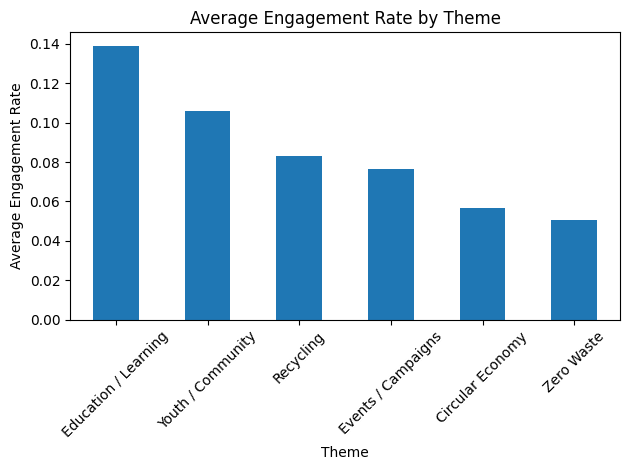

In [51]:
theme_engagement = theme_engagement[theme_engagement.index != 'Other']

theme_engagement['avg_engagement_rate'].plot(kind='bar')
plt.title('Average Engagement Rate by Theme')
plt.xlabel('Theme')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Education and learning content shows the highest engagement efficiency, followed by youth/community and recycling themes. In contrast, circular economy and zero waste exhibit lower engagement rates. This suggests that educational and community-driven content is more effective in generating interactions, while more abstract themes may require different presentation strategies.

**Platform-wise Theme Performance**

In [52]:
theme_platform = rq1_df.groupby(['platform', 'theme']).agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    count=('engagement', 'count')
).reset_index()

theme_platform.sort_values(by='avg_engagement_rate', ascending=False).head(15)

,platform,theme,avg_engagement_rate,count
23,youtube,Other,0.935354,8
21,youtube,Education / Learning,0.880332,13
22,youtube,Events / Campaigns,0.603865,2
24,youtube,Recycling,0.498551,6
20,youtube,Circular Economy,0.369430,2
18,linkedin,Youth / Community,0.175890,4
15,linkedin,Education / Learning,0.097591,46
14,linkedin,Circular Economy,0.088959,8
12,instagram,Youth / Community,0.082831,3
16,linkedin,Events / Campaigns,0.074662,17


In [53]:
pivot_theme_platform = theme_platform.pivot(
    index='theme',
    columns='platform',
    values='avg_engagement_rate'
)

pivot_theme_platform

platform,facebook,instagram,linkedin,youtube
theme,,,,
Circular Economy,0.025021,0.043528,0.088959,0.369430
Education / Learning,0.025074,0.068290,0.097591,0.880332
Events / Campaigns,0.032774,0.065618,0.074662,0.603865
Other,0.022565,0.022727,NaN,0.935354
Recycling,0.022115,0.055774,0.042539,0.498551
Youth / Community,0.034897,0.082831,0.175890,NaN
Zero Waste,0.026106,0.070693,0.066667,NaN


**Visualization 1: Heatmap of Theme Performance Across Platforms** - This heatmap compares average engagement rates across themes and platforms. Darker cells indicate stronger performance, making it easier to identify which themes perform best on which platforms.

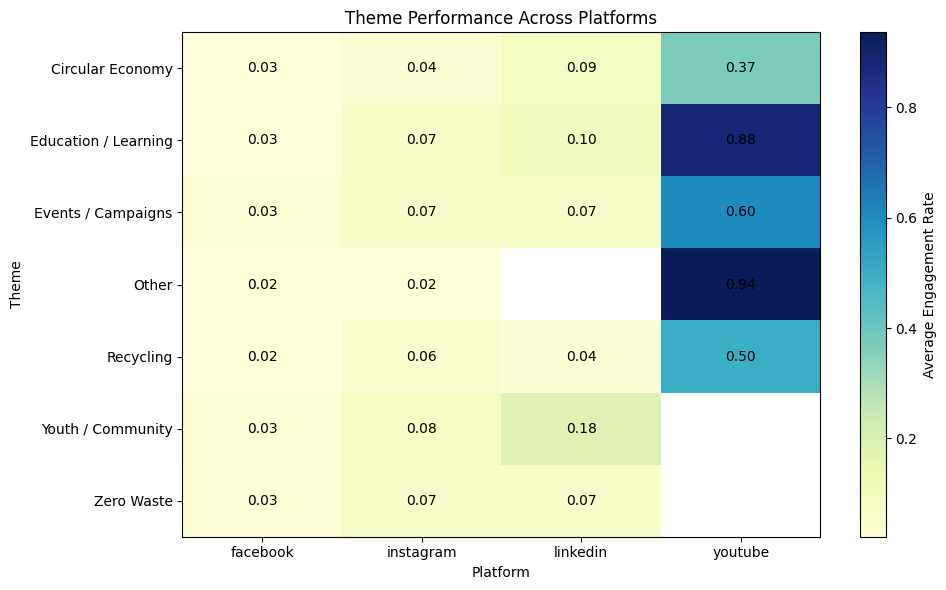

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(pivot_theme_platform, aspect='auto', cmap='YlGnBu')

plt.colorbar(label='Average Engagement Rate')
plt.xticks(ticks=range(len(pivot_theme_platform.columns)), labels=pivot_theme_platform.columns)
plt.yticks(ticks=range(len(pivot_theme_platform.index)), labels=pivot_theme_platform.index)

plt.title('Theme Performance Across Platforms')
plt.xlabel('Platform')
plt.ylabel('Theme')

# annotate values
for i in range(len(pivot_theme_platform.index)):
    for j in range(len(pivot_theme_platform.columns)):
        val = pivot_theme_platform.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

#### Theme Performance Across Platforms (Heatmap)
- YouTube shows significantly higher engagement rates across all themes compared to other platforms. This is expected because engagement on YouTube is calculated differently (engaged views / views), making it structurally higher.
- Among all themes, **Education / Learning** performs the best across platforms, especially on YouTube.
- **Events / Campaigns** and **Recycling** also show strong performance on YouTube.
- On LinkedIn, **Youth / Community** stands out as the highest-performing theme.
- Facebook shows relatively low and consistent engagement across all themes, indicating less variation in theme effectiveness.
This indicates that theme effectiveness is platform-dependent.

Visualization 2: Grouped Bar Chart for Theme × Platform - This grouped bar chart shows how each theme performs across different platforms. It helps identify whether a theme is consistently effective or works better on specific platforms.


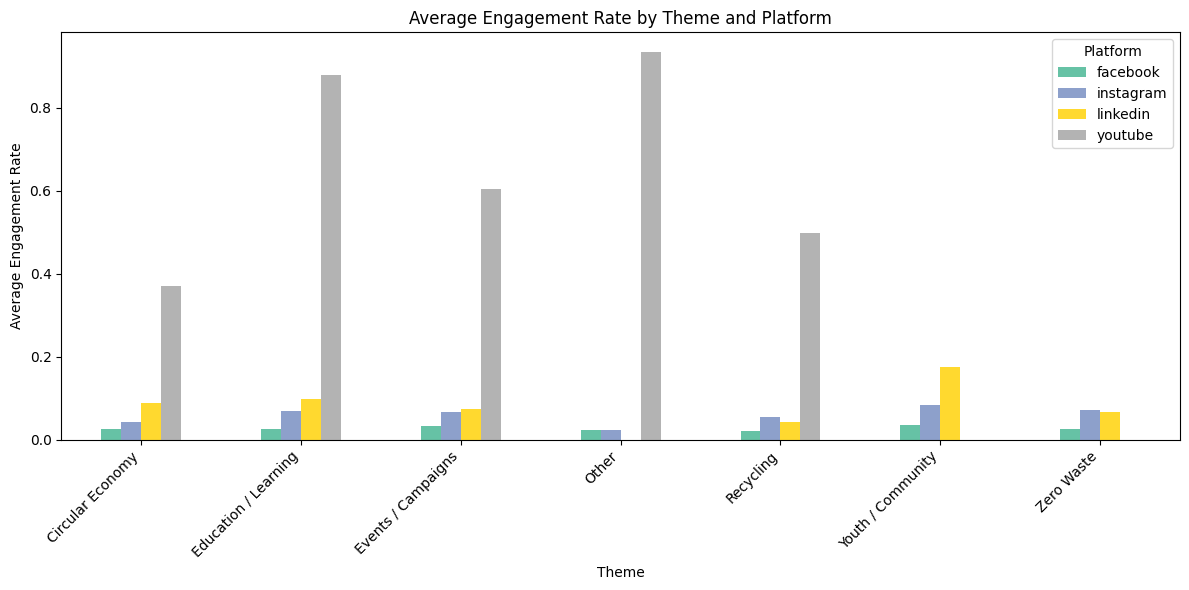

In [55]:
theme_platform_plot = theme_platform.copy()

pivot_bar = theme_platform_plot.pivot(index='theme', columns='platform', values='avg_engagement_rate')
pivot_bar.plot(kind='bar', figsize=(12, 6), colormap='Set2')

plt.title('Average Engagement Rate by Theme and Platform')
plt.xlabel('Theme')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform')
plt.tight_layout()
plt.show()

#### Average Engagement Rate by Theme and Platform

- YouTube consistently outperforms all other platforms across every theme.
- **Education / Learning** emerges as the strongest theme overall, especially on YouTube.
- **Youth / Community** performs particularly well on LinkedIn, suggesting that professional/community-driven content resonates more with LinkedIn audiences.
- Instagram shows moderate engagement across themes, with slightly better performance for **Youth / Community** and **Zero Waste**.
- Facebook remains the lowest-performing platform across all themes.

The dominance of YouTube in this chart is influenced by the **different definition of engagement rate**, making cross-platform comparison less direct.

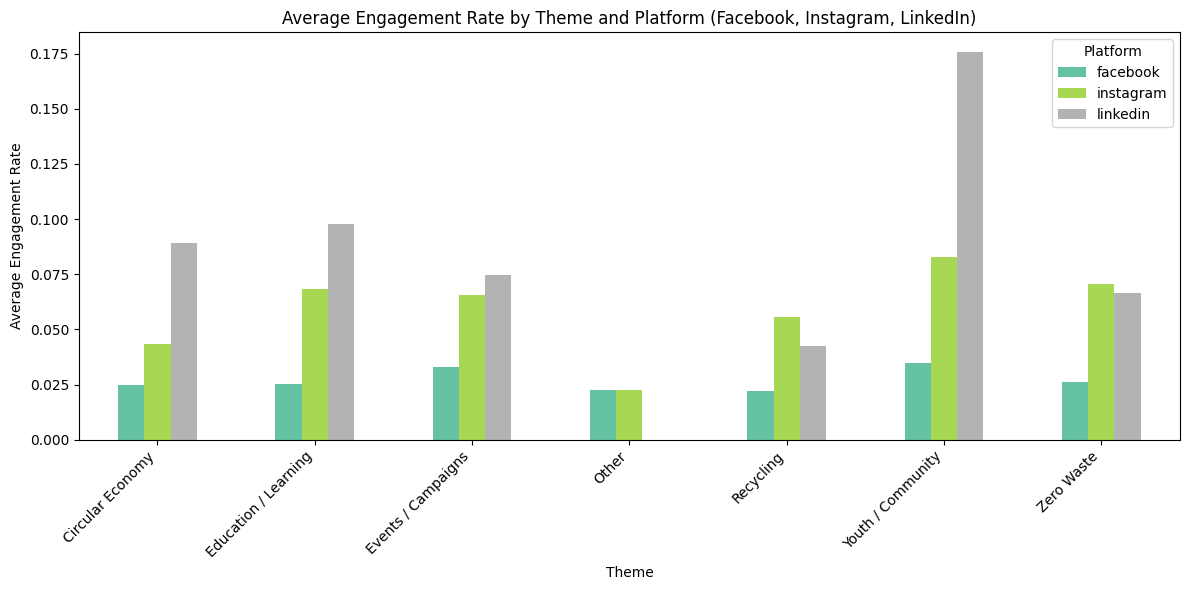

In [56]:
pivot_bar_no_yt = pivot_bar.drop(columns=['youtube'], errors='ignore')
pivot_bar_no_yt.plot(kind='bar',figsize=(12, 6),colormap='Set2')
plt.title('Average Engagement Rate by Theme and Platform (Facebook, Instagram, LinkedIn)')
plt.xlabel('Theme')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform')
plt.tight_layout()
plt.show()

#### Theme Performance Across Facebook, Instagram, and LinkedIn

Excluding YouTube, LinkedIn and Instagram show higher engagement than Facebook. Youth / Community and Education / Learning perform best, highlighting the importance of platform-specific content strategies.

### RQ1 Subquestion: Are certain sustainability themes consistently high-performing across platforms, or are they platform-specific?

The analysis shows a **mixed pattern**, indicating that both consistency and platform-specific behavior exist.

**Consistently High-Performing Themes:**
- **Education / Learning** performs strongly across all platforms.
- It has the highest or near-highest engagement on Facebook, Instagram, LinkedIn, and YouTube.
- This suggests that **informational and educational content has universal appeal**, regardless of platform.

**Platform-Specific Themes:**
- **Youth / Community** performs exceptionally well on LinkedIn but not as strongly on Facebook or Instagram.
- **Recycling** shows stronger performance on YouTube compared to other platforms.
- **Events / Campaigns** perform well on YouTube and moderately on Instagram but less on Facebook.
- **Zero Waste and Circular Economy** show moderate and inconsistent performance across platforms.

**Platform Observations:**
- **LinkedIn favors community and professional-oriented content** (e.g., Youth / Community, Education).
- **Instagram supports visually engaging and lifestyle-related themes** (e.g., Youth, Zero Waste).
- **Facebook shows low variation**, indicating weaker sensitivity to theme differences.
- **YouTube dominates engagement overall**, but due to different engagement metrics, it should be interpreted separately.

**Conclusion:**
There is **no single theme that universally dominates across all platforms**. While **Education / Learning is consistently strong**, most themes are **platform-dependent**, highlighting the importance of tailoring content strategy to each platform.

### Create Theme × Format Table

In [57]:
theme_format = (rq1_df
    .groupby(['theme', 'post_type_standardized'])
    .agg(avg_engagement_rate=('engagement_rate', 'mean'), count=('engagement_rate', 'count'))
    .reset_index())

theme_format = theme_format.sort_values(by='avg_engagement_rate', ascending=False)

theme_format.head(10)

,theme,post_type_standardized,avg_engagement_rate,count
19,Other,video,0.833584,9
11,Education / Learning,video,0.485257,24
25,Recycling,video,0.242171,13
16,Events / Campaigns,video,0.234836,6
26,Youth / Community,Organic,0.230387,3
32,Zero Waste,carousel,0.163265,1
5,Circular Economy,video,0.111601,7
6,Education / Learning,Organic,0.099594,45
0,Circular Economy,Organic,0.088959,8
12,Events / Campaigns,Organic,0.074662,17


In [58]:
pivot_theme_format = theme_format.pivot(index='theme',columns='post_type_standardized',values='avg_engagement_rate')

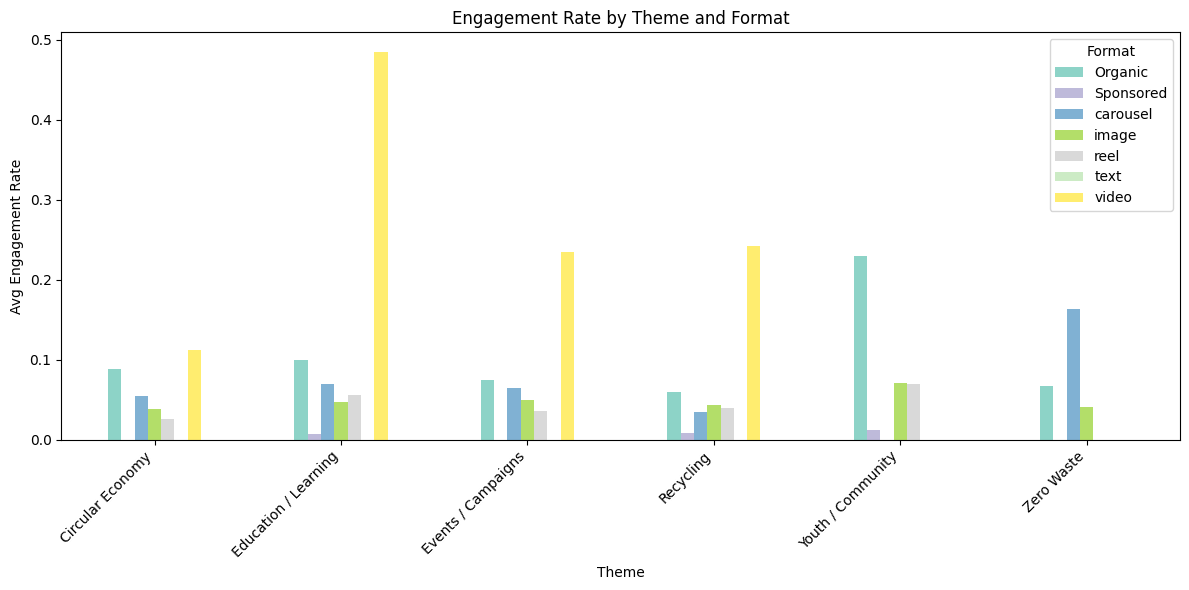

In [59]:
filtered = pivot_theme_format.drop(index='Other', errors='ignore')

filtered.plot(kind='bar', figsize=(12, 6), colormap='Set3')

plt.title('Engagement Rate by Theme and Format')
plt.xlabel('Theme')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Format')

plt.tight_layout()
plt.show()

#### Theme × Format Interaction

Video formats show the highest engagement across most themes, though this is largely influenced by YouTube’s engagement definition. Across other formats, image and carousel perform moderately well depending on the theme, while text-based formats generally underperform. Organic content appears stronger for Youth / Community, reflecting LinkedIn-driven engagement patterns. Overall, Engagement is driven by a strong interaction between theme and format, with **video emerging as the most effective format across themes**.

#### Top 5 Best Performin theme + format overall

In [60]:
top_theme_format = (rq1_df.groupby(['theme', 'post_type_standardized'])
    .agg(avg_engagement_rate=('engagement_rate', 'mean'),
        count=('engagement_rate', 'count'))
    .reset_index())

# apply filter
top_theme_format_filtered = top_theme_format[
    (top_theme_format['count'] >= 5) &
    (top_theme_format['theme'].str.lower() != 'other')
]

top_5_theme_format = top_theme_format_filtered.sort_values(by='avg_engagement_rate',ascending=False).head(5)

top_5_theme_format

,theme,post_type_standardized,avg_engagement_rate,count
11,Education / Learning,video,0.485257,24
25,Recycling,video,0.242171,13
16,Events / Campaigns,video,0.234836,6
5,Circular Economy,video,0.111601,7
6,Education / Learning,Organic,0.099594,45


The top-performing theme–format combinations are primarily driven by video content, with Education / Learning + Video achieving the highest engagement. Recycling and Events also perform well in video format. However, this pattern is influenced by YouTube’s engagement definition. Education / Learning with organic content also shows strong performance, indicating consistent baseline appeal across formats.

**Conclusion:**  High engagement is concentrated in **video-based content**, particularly for educational and action-driven themes.

#### Theme X Format X Platform

In [61]:
theme_format_platform = (
    rq1_df.groupby(['theme', 'post_type_standardized', 'platform'])
    .agg(avg_engagement_rate=('engagement_rate', 'mean'),
        count=('engagement_rate', 'count'))
    .reset_index())

# sort for inspection
theme_format_platform_sorted = theme_format_platform.sort_values(by='avg_engagement_rate',
    ascending=False)

In [62]:
theme_format_platform_filtered = theme_format_platform[
    theme_format_platform['count'] >= 5]

theme_format_platform_filtered_sorted = theme_format_platform_filtered.sort_values(
    by='avg_engagement_rate',ascending=False)

theme_format_platform_filtered_sorted.head(10)

,theme,post_type_standardized,platform,avg_engagement_rate,count
27,Other,video,youtube,0.935354,8
15,Education / Learning,video,youtube,0.880332,13
36,Recycling,video,youtube,0.498551,6
8,Education / Learning,Organic,linkedin,0.099594,45
0,Circular Economy,Organic,linkedin,0.088959,8
19,Events / Campaigns,image,instagram,0.074958,13
16,Events / Campaigns,Organic,linkedin,0.074662,17
12,Education / Learning,image,instagram,0.073057,24
10,Education / Learning,carousel,instagram,0.070177,8
32,Recycling,image,instagram,0.068450,13


### Top 5 Per Platform

In [63]:
top_5_per_platform = (theme_format_platform_filtered
    .sort_values(['platform', 'avg_engagement_rate'], ascending=[True, False])
    .groupby('platform').head(5))

top_5_per_platform

,theme,post_type_standardized,platform,avg_engagement_rate,count
2,Circular Economy,image,facebook,0.032720,14
18,Events / Campaigns,image,facebook,0.028094,15
11,Education / Learning,image,facebook,0.027460,31
45,Zero Waste,image,facebook,0.026106,8
31,Recycling,image,facebook,0.022584,16
19,Events / Campaigns,image,instagram,0.074958,13
12,Education / Learning,image,instagram,0.073057,24
10,Education / Learning,carousel,instagram,0.070177,8
32,Recycling,image,instagram,0.068450,13
46,Zero Waste,image,instagram,0.057469,7


##### Top Performing Combinations by Platform

Performance varies significantly by platform:
- Facebook: Image-based content dominates across all themes.
- Instagram: Both image and carousel formats perform well, especially for Education.
- LinkedIn: Organic posts perform best, particularly for Education and Circular Economy.
- YouTube: Video overwhelmingly dominates, especially for Education and Recycling.

**Conclusion:**  Each platform favors a different format, reinforcing the need for **platform-specific content strategies**.

### Best Format per theme

In [64]:
best_format_per_theme = (theme_format_platform_filtered
    .sort_values(['theme', 'avg_engagement_rate'], ascending=[True, False])
    .groupby('theme').first().reset_index())

best_format_per_theme

,theme,post_type_standardized,platform,avg_engagement_rate,count
0,Circular Economy,Organic,linkedin,0.088959,8
1,Education / Learning,video,youtube,0.880332,13
2,Events / Campaigns,image,instagram,0.074958,13
3,Other,video,youtube,0.935354,8
4,Recycling,video,youtube,0.498551,6
5,Zero Waste,image,instagram,0.057469,7


##### Best Format per Theme

Each theme has a distinct optimal format:

- Education / Learning → Video (YouTube)
- Recycling → Video (YouTube)
- Circular Economy → Organic (LinkedIn)
- Events / Campaigns → Image (Instagram)
- Zero Waste → Image (Instagram)

**Conclusion:** There is no universal best format - **optimal format depends on the theme–platform combination**.

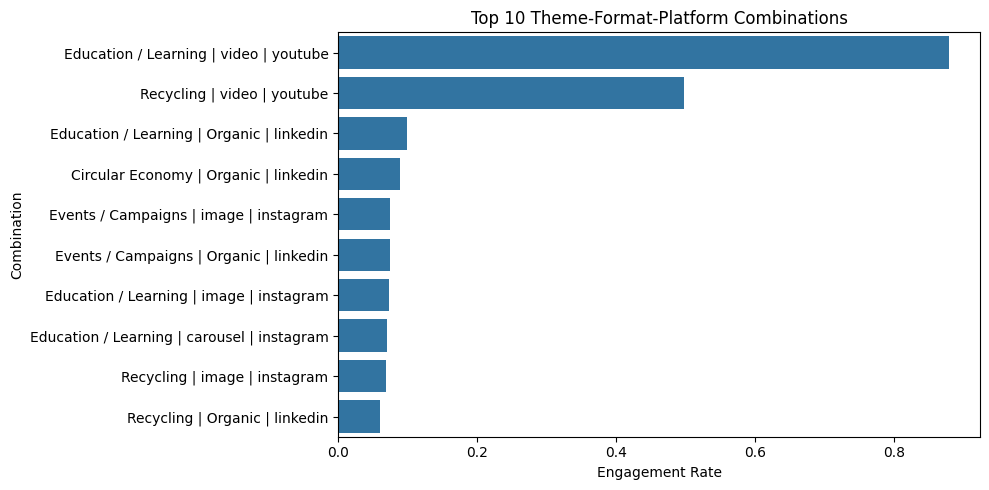

In [65]:
# Highlight only top combinations
top_10 = theme_format_platform_filtered.sort_values(by='avg_engagement_rate', ascending=False).head(10)
# Highlight only top combinations
top_10 = theme_format_platform_filtered[
    theme_format_platform_filtered['theme'].str.lower() != 'other'
].sort_values(by='avg_engagement_rate', ascending=False).head(10)

import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10,
    x='avg_engagement_rate',
    y=top_10['theme'] + " | " + top_10['post_type_standardized'] + " | " + top_10['platform'])

plt.title('Top 10 Theme-Format-Platform Combinations')
plt.xlabel('Engagement Rate')
plt.ylabel('Combination')
plt.tight_layout()
plt.show()

The top-performing combinations are dominated by YouTube video content, particularly for Education / Learning and Recycling. Outside of YouTube, LinkedIn organic posts and Instagram image-based content perform strongly for specific themes. This highlights that optimal performance depends on a combination of theme, format, and platform rather than a single factor.

### RQ1: 

How do content themes and delivery formats jointly influence engagement efficiency across platforms? Are themes consistent or platform-specific?

This study examined how sustainability-related content themes and delivery formats interact to influence engagement across social media platforms.

### Key Findings:
Key Findings:

1. Theme Impact

- Education / Learning is the most consistently high-performing theme across platforms.
- Youth / Community shows strong engagement, particularly on LinkedIn and Instagram.
- Themes such as Circular Economy and Zero Waste exhibit comparatively lower engagement.

2. Format Impact

- Video content consistently achieves the highest engagement across themes.
- Dynamic formats (video, reels) outperform static formats (text, images).
- Platform-specific preferences:
    - YouTube - Video
    - Instagram - Reels / Images / Carousel
    - LinkedIn - Organic posts
    - Facebook - Image-based content

3. Theme × Format Interaction

- Engagement is driven by the interaction between theme and format, rather than either independently.
- Top-performing combinations include:
  - Education / Learning + Video
  - Recycling + Video
  - Events / Campaigns + Video
This indicates strong interaction effects in content performance.

4. Platform-Specific Behavior

Engagement patterns vary across platforms:
- LinkedIn favors educational and community-driven content
- Instagram favors visually engaging formats
- Facebook shows relatively stable but lower engagement variation
- YouTube demonstrates high engagement due to video-centric consumption

**Sub-question: Are themes consistent or platform-specific?**

The results show a hybrid pattern:

- Consistent Theme:
Education / Learning performs well across all platforms
- Platform-Specific Themes:
Youth / Community - Strong on LinkedIn
- Recycling - Strong on YouTube
Events / Campaigns - Platform-dependent

Final Conclusion:

Content performance is driven by a three-way interaction between theme, format, and platform. There is no universally optimal strategy; engagement is maximized by aligning the appropriate theme with the most effective format for each platform.

### Additional Analysis - Not for the purpose of Report and not a part of any of the Research Questions
#### Hashtag Analysis

**Hashtag Extraction** - Hashtags were extracted from the post content using regular expressions. All hashtags were converted to lowercase to ensure consistency across variations

In [66]:
import re
def extract_hashtags(text):
    if pd.isna(text):
        return []
    return re.findall(r'#\w+', text.lower())

rq1_df['hashtags'] = rq1_df['content'].apply(extract_hashtags)

In [67]:
rq1_df['hashtag_count'] = rq1_df['hashtags'].apply(len)

**Hashtag Bucketing** - Posts were grouped based on the number of hashtags used (e.g., 1-2, 3-5, 6-8, 8+). This allows for a more structured analysis of how hashtag quantity influences engagement.

In [68]:
def hashtag_bucket(x):
    if x == 0:
        return '0'
    elif x <= 2:
        return '1-2'
    elif x <= 5:
        return '3-5'
    elif x <= 8:
        return '6-8'
    else:
        return '8+'

rq1_df['hashtag_bucket'] = rq1_df['hashtag_count'].apply(hashtag_bucket)

**Hashtag Bucket vs Engagement** - This analysis examines how engagement varies across different hashtag usage ranges. It helps identify whether there is an optimal number of hashtags for maximizing engagement.

In [69]:
hashtag_bucket_analysis = (rq1_df
    .groupby('hashtag_bucket').agg(
        avg_engagement_rate=('engagement_rate', 'mean'),count=('engagement_rate', 'count'))
    .reset_index())

hashtag_bucket_analysis

,hashtag_bucket,avg_engagement_rate,count
0,0,0.551830,46
1,3-5,0.053399,141
2,6-8,0.055302,129
3,8+,0.046826,38


**Hashtag Usage Across Platforms** - This analysis explores how the effectiveness of hashtag usage varies across platforms. It helps determine whether different platforms benefit from different hashtag strategies.

In [70]:
hashtag_platform_analysis = (rq1_df.groupby(['platform', 'hashtag_bucket'])
    .agg(avg_engagement_rate=('engagement_rate', 'mean'),
        count=('engagement_rate', 'count')).reset_index())

hashtag_platform_analysis

,platform,hashtag_bucket,avg_engagement_rate,count
0,facebook,0,0.015718,4
1,facebook,3-5,0.031230,41
2,facebook,6-8,0.025927,52
3,facebook,8+,0.018033,22
4,instagram,0,0.027544,3
5,instagram,3-5,0.054183,62
6,instagram,6-8,0.067812,49
7,instagram,8+,0.104700,4
8,linkedin,0,0.171703,8
9,linkedin,3-5,0.076040,38


In [71]:
pivot_hashtag_platform = hashtag_platform_analysis.pivot(index='hashtag_bucket',
    columns='platform',values='avg_engagement_rate')

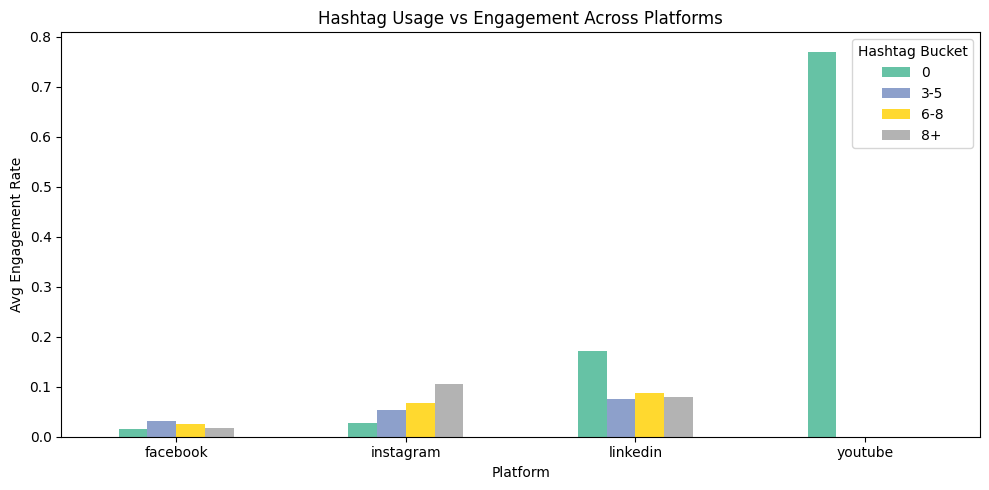

In [72]:
pivot_hashtag_platform = hashtag_platform_analysis.pivot(index='platform',          # <-- X-axis
    columns='hashtag_bucket',  # <-- Legend
    values='avg_engagement_rate')

pivot_hashtag_platform.plot(kind='bar',figsize=(10, 5),colormap='Set2')

plt.title('Hashtag Usage vs Engagement Across Platforms')
plt.xlabel('Platform')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=0)
plt.legend(title='Hashtag Bucket')

plt.tight_layout()
plt.show()

##### Hashtag Usage vs Engagement Across Platforms
Hashtag effectiveness varies across platforms. Instagram shows improved engagement with higher hashtag usage, while LinkedIn and YouTube perform well even with minimal or no hashtags. Facebook shows limited sensitivity to hashtag count.
Top-performing hashtags are highly specific (e.g., education and youth-focused), indicating that relevance matters more than volume.

In [73]:
# explode hashtags
hashtag_expanded = rq1_df.explode('hashtags')

# remove empty / null
hashtag_expanded = hashtag_expanded[hashtag_expanded['hashtags'].notna()]
hashtag_expanded = hashtag_expanded[hashtag_expanded['hashtags'] != '']

# aggregate
hashtag_performance = (hashtag_expanded.groupby('hashtags')
    .agg(avg_engagement_rate=('engagement_rate', 'mean'), count=('engagement_rate', 'count')).reset_index())

hashtag_performance_filtered = hashtag_performance[hashtag_performance['count'] >= 5]

# sort
top_hashtags = hashtag_performance_filtered.sort_values(by='avg_engagement_rate',ascending=False).head(10)
top_hashtags

,hashtags,avg_engagement_rate,count
8,#classroominnovation,0.155708,7
99,#teacherresources,0.128141,12
123,#yunusthailand,0.100470,5
28,#empowereducators,0.098900,8
122,#youthleadership,0.091321,5
120,#youthforzerowaste,0.081247,35
127,#zerowastefuture,0.081247,35
91,#sustainabilityinschools,0.079414,11
89,#sustainabilityeducation,0.077381,22
125,#zerowasteeducation,0.059120,111


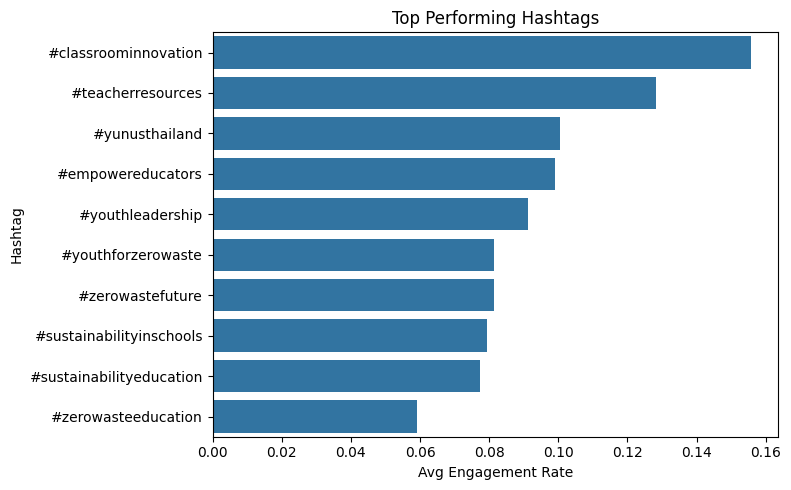

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=top_hashtags, x='avg_engagement_rate', y='hashtags')

plt.title('Top Performing Hashtags')
plt.xlabel('Avg Engagement Rate')
plt.ylabel('Hashtag')

plt.tight_layout()
plt.show()

##### Top Performing Hashtags

- High-performing hashtags are **highly specific and niche**, such as:#classroominnovation, #teacherresources, #empowereducators
- Many top hashtags are strongly aligned with **education and youth-focused themes**, reinforcing earlier findings.
- Broad or generic sustainability hashtags are not present among top performers, indicating that **specificity drives engagement**.
- Hashtags related to **education, youth leadership, and actionable initiatives** tend to perform better than general awareness tags.

**Conclusion:** Hashtag effectiveness is driven by **relevance and specificity**, not popularity. Targeted hashtags aligned with content themes significantly improve engagement outcomes.

### Research Question 2

Audience Demographics and Engagement Behavior

**Research Question: How do audience demographics and geographic segments - including age group, country, and platform source - vary in their engagement and download behavior on the Waste Hero website?**

Objective & Approach:

This analysis focuses on understanding who engages and converts, complementing RQ1’s focus on content performance. Using Google Analytics data, we examine user behavior across age groups, countries, and traffic sources by comparing engagement metrics and download activity. To ensure fair comparison, we analyze engagement-to-download efficiency, distinguishing between high-traffic audiences and high-conversion audiences. Traffic sources are grouped into categories (e.g., organic search, social, email, campaign) to capture differences in acquisition channels. Additionally, we focus on key geographic segments to identify high-engagement and underrepresented markets. This approach enables a structured evaluation of how different audience segments interact with the platform, highlighting variations in both engagement intensity and conversion behavior.

**Age-based Engagement Analysis** - We combine page view and user engagement data across age groups to compute a normalized engagement rate. This allows us to compare how efficiently different age segments interact with content, independent of their overall volume.

In [75]:
# --- AGE DATA ---

# rename columns for consistency
age_visit = ga_age_visit.rename(columns={'Age': 'age', 'Event count': 'views'})
age_eng = ga_age_eng.rename(columns={'Age': 'age','Event count': 'engagements'})
# merge
age_df = age_visit[['age', 'views']].merge(age_eng[['age', 'engagements']],on='age',how='inner')
# compute engagement rate
age_df['engagement_rate'] = age_df['engagements'] / age_df['views']
# sort
age_df = age_df.sort_values(by='engagement_rate', ascending=False)
age_df.head(10)

,age,views,engagements,engagement_rate
2,18-24,57196,20340,0.355619
1,25-34,89792,31066,0.345977
4,45-54,17955,6004,0.334392
5,55-64,13475,4468,0.331577
6,65+,9480,3105,0.327532
3,35-44,39831,12309,0.309031
0,unknown,1008911,240822,0.238695


**Platform-based Engagement Analysis** - We merge visit and engagement data across traffic sources (platforms) and compute engagement rates. This helps us understand how different acquisition channels contribute to user interaction quality.

In [76]:
# --- PLATFORM DATA ---
# rename
platform_visit = ga_platform_visit.rename(columns={'Session source/medium': 'platform_raw',
    'Event count': 'views'})

platform_eng = ga_platform_eng.rename(columns={'Session source/medium': 'platform_raw',
    'Event count': 'engagements'})

# merge
platform_df = platform_visit[['platform_raw', 'views']].merge(platform_eng[['platform_raw', 'engagements']],on='platform_raw',
    how='inner')

# engagement rate
platform_df['engagement_rate'] = platform_df['engagements'] / platform_df['views']

platform_df.head(10)

,platform_raw,views,engagements,engagement_rate
0,google / cpc,844086,255043,0.302153
1,(direct) / (none),157359,27140,0.172472
2,l.facebook.com / referral,111940,13760,0.122923
3,m.facebook.com / referral,23777,1821,0.076587
4,(data not available),20603,4152,0.201524
5,(Porvir) Social Media Posts / (Porvir) Social ...,10640,1073,0.100846
6,google / organic,9908,4266,0.430561
7,ShareMyLesson Campaign / ShareMyLesson Campaign,4573,501,0.109556
8,(NEA) Ad Campaign / (NEA) Ad Campaign,5217,1581,0.303048
9,(not set),27743,761,0.027430


In [77]:
platform_visit['platform_raw'].unique()

<ArrowStringArray>
[                                             'google / cpc',
                                         '(direct) / (none)',
                                 'l.facebook.com / referral',
                                 'm.facebook.com / referral',
                                      '(data not available)',
 '(Porvir) Social Media Posts / (Porvir) Social Media Posts',
                                          'google / organic',
           'ShareMyLesson Campaign / ShareMyLesson Campaign',
                     '(NEA) Ad Campaign / (NEA) Ad Campaign',
                                                 '(not set)',
 ...
                                    'vercel.live / referral',
                              'view.genially.com / referral',
                            'vn.search.yahoo.com / referral',
                                   'vnseameo.org / referral',
                                 'webhitlist.com / referral',
                         'webmail1.earthlink.n

**Country-based Engagement Analysis** - We analyze engagement efficiency across countries by combining views and engagement metrics. To ensure meaningful comparisons, we focus on the top countries by visibility, highlighting key geographic segments driving engagement.

In [78]:
# --- COUNTRY DATA ---

country_visit = ga_country_visit.rename(columns={'Country': 'country',
    'Event count': 'views'})

country_eng = ga_country_eng.rename(columns={'Country': 'country',
    'Event count': 'engagements'})

# merge
country_df = country_visit[['country', 'views']].merge(country_eng[['country', 'engagements']],on='country',how='inner')

# engagement rate
country_df['engagement_rate'] = country_df['engagements'] / country_df['views']

# top 10 by views (important)
country_df = country_df.sort_values(by='views', ascending=False).head(10)

country_df

,country,views,engagements,engagement_rate
0,India,536985,124354,0.231578
1,Philippines,391065,112817,0.288487
2,Mexico,65921,17087,0.259204
3,Brazil,57234,13251,0.231523
4,United States,43790,12246,0.279653
5,South Africa,34020,14865,0.436949
6,Indonesia,22997,5540,0.240901
7,Spain,13841,1971,0.142403
8,France,11455,1685,0.147097
10,Thailand,10090,4375,0.433598


**Platform Grouping and Normalization** - To address the high variability and noise in raw traffic source data, individual platform sources were grouped into broader, interpretable categories such as Google, Facebook, Instagram, YouTube, Email/Direct, Campaign, and Referral/Other. This grouping ensures consistent comparison across acquisition channels while preserving meaningful distinctions between intent-driven, social, and campaign-driven traffic sources.

In [79]:
def map_platform(x):
    x = str(x).lower()
    
    # Google / Search
    if 'google' in x or 'bing' in x or 'yahoo' in x or 'duckduckgo' in x or 'baidu' in x:
        return 'Google'
    
    # Facebook
    elif 'facebook' in x or 'messenger' in x:
        return 'Facebook'
    
    # Instagram
    elif 'instagram' in x:
        return 'Instagram'
    
    # YouTube
    elif 'youtube' in x:
        return 'YouTube'
    
    # Email / Direct
    elif 'direct' in x or 'email' in x or 'mail' in x:
        return 'Email / Direct'

     # Campaign (highest priority)
    elif 'campaign' in x or 'promotion' in x or 'ads' in x:
        return 'Campaign'
    
    # Everything else
    else:
        return 'Referral / Other'


# apply mapping
platform_df['platform_group'] = platform_df['platform_raw'].apply(map_platform)

In [80]:
# aggregate after grouping
platform_grouped = (platform_df.groupby('platform_group')
    .agg(views=('views', 'sum'),engagements=('engagements', 'sum')).reset_index())
# compute engagement rate
platform_grouped['engagement_rate'] = (platform_grouped['engagements'] / platform_grouped['views'])
# sort
platform_grouped = platform_grouped.sort_values(by='engagement_rate', ascending=False)

platform_grouped

,platform_group,views,engagements,engagement_rate
4,Instagram,2183,748,0.342648
6,YouTube,1196,394,0.329431
3,Google,856097,260511,0.304301
0,Campaign,15543,4192,0.269703
1,Email / Direct,158955,27849,0.175201
5,Referral / Other,63333,7845,0.123869
2,Facebook,139193,16574,0.119072


**Incorporating High-Intent User Actions**

To extend the analysis beyond interaction-level engagement, download events (file views) are incorporated as a proxy for high-intent user behavior. Download rate is computed as the ratio of downloads to total views, enabling a deeper understanding of which audience segments not only engage with content but also take meaningful actions. This distinction allows us to separate passive interaction from active content consumption.

In [81]:
age_download = ga_age_download.rename(columns={'Age': 'age','Event count': 'downloads'})

# merge into existing age_df
age_df = age_df.merge(age_download[['age', 'downloads']],
    on='age',how='left')

# compute download rate
age_df['download_rate'] = age_df['downloads'] / age_df['views']
age_df

,age,views,engagements,engagement_rate,downloads,download_rate
0,18-24,57196,20340,0.355619,4528,0.079166
1,25-34,89792,31066,0.345977,4457,0.049637
2,45-54,17955,6004,0.334392,1591,0.088610
3,55-64,13475,4468,0.331577,458,0.033989
4,65+,9480,3105,0.327532,486,0.051266
5,35-44,39831,12309,0.309031,2143,0.053802
6,unknown,1008911,240822,0.238695,33502,0.033206


In [82]:
platform_download = ga_platform_download.rename(columns={
    'Session source/medium': 'platform_raw',
    'Event count': 'downloads'})

# apply SAME mapping
platform_download['platform_group'] = platform_download['platform_raw'].apply(map_platform)

# aggregate downloads
platform_download_grouped = (platform_download.groupby('platform_group')
    .agg(downloads=('downloads', 'sum')).reset_index())

# merge with existing grouped df
platform_grouped = platform_grouped.merge(platform_download_grouped,on='platform_group',how='left')

# compute download rate
platform_grouped['download_rate'] = (platform_grouped['downloads'] / platform_grouped['views'])
platform_grouped

,platform_group,views,engagements,engagement_rate,downloads,download_rate
0,Instagram,2183,748,0.342648,370,0.169492
1,YouTube,1196,394,0.329431,587,0.490803
2,Google,856097,260511,0.304301,16798,0.019622
3,Campaign,15543,4192,0.269703,2700,0.173712
4,Email / Direct,158955,27849,0.175201,19929,0.125375
5,Referral / Other,63333,7845,0.123869,5330,0.084158
6,Facebook,139193,16574,0.119072,1451,0.010424


In [83]:
country_download = ga_country_download.rename(columns={'Country': 'country',
    'Event count': 'downloads'})

# merge
country_df = country_df.merge(country_download[['country', 'downloads']],
    on='country',how='left')

# compute download rate
country_df['download_rate'] = country_df['downloads'] / country_df['views']
country_df

,country,views,engagements,engagement_rate,downloads,download_rate
0,India,536985,124354,0.231578,2868,0.005341
1,Philippines,391065,112817,0.288487,12593,0.032202
2,Mexico,65921,17087,0.259204,978,0.014836
3,Brazil,57234,13251,0.231523,4307,0.075252
4,United States,43790,12246,0.279653,10615,0.242407
5,South Africa,34020,14865,0.436949,141,0.004145
6,Indonesia,22997,5540,0.240901,2192,0.095317
7,Spain,13841,1971,0.142403,261,0.018857
8,France,11455,1685,0.147097,89,0.007770
9,Thailand,10090,4375,0.433598,3415,0.338454


**Data-Driven Behavioral Segmentation**

To avoid arbitrary threshold selection, engagement and download thresholds are derived using percentile-based cutoffs. Specifically, the 75th percentile is used to define “high” engagement and “high” intent segments. This ensures that segmentation is grounded in the underlying data distribution rather than predefined values. By using relative thresholds, the analysis adapts to variations in metric scale across age groups, platforms, and countries, resulting in a more robust and statistically defensible classification of audience behavior.

In [84]:
# thresholds from data
eng_threshold = age_df['engagement_rate'].quantile(0.75)
dl_threshold = age_df['download_rate'].quantile(0.75)

In [85]:
def classify_user(row):
    if row['engagement_rate'] >= eng_threshold and row['download_rate'] >= dl_threshold:
        return 'High Engagement + High Intent'
    elif row['engagement_rate'] >= eng_threshold:
        return 'High Engagement Only'
    elif row['download_rate'] >= dl_threshold:
        return 'High Intent Only'
    else:
        return 'Low Engagement / Low Intent'

In [86]:
age_df['segment'] = age_df.apply(classify_user, axis=1)
age_df

,age,views,engagements,engagement_rate,downloads,download_rate,segment
0,18-24,57196,20340,0.355619,4528,0.079166,High Engagement + High Intent
1,25-34,89792,31066,0.345977,4457,0.049637,High Engagement Only
2,45-54,17955,6004,0.334392,1591,0.088610,High Intent Only
3,55-64,13475,4468,0.331577,458,0.033989,Low Engagement / Low Intent
4,65+,9480,3105,0.327532,486,0.051266,Low Engagement / Low Intent
5,35-44,39831,12309,0.309031,2143,0.053802,Low Engagement / Low Intent
6,unknown,1008911,240822,0.238695,33502,0.033206,Low Engagement / Low Intent


In [87]:
platform_grouped['segment'] = platform_grouped.apply(classify_user, axis=1)
platform_grouped

,platform_group,views,engagements,engagement_rate,downloads,download_rate,segment
0,Instagram,2183,748,0.342648,370,0.169492,High Engagement + High Intent
1,YouTube,1196,394,0.329431,587,0.490803,High Intent Only
2,Google,856097,260511,0.304301,16798,0.019622,Low Engagement / Low Intent
3,Campaign,15543,4192,0.269703,2700,0.173712,High Intent Only
4,Email / Direct,158955,27849,0.175201,19929,0.125375,High Intent Only
5,Referral / Other,63333,7845,0.123869,5330,0.084158,High Intent Only
6,Facebook,139193,16574,0.119072,1451,0.010424,Low Engagement / Low Intent


In [88]:
country_df['segment'] = country_df.apply(classify_user, axis=1)
country_df

,country,views,engagements,engagement_rate,downloads,download_rate,segment
0,India,536985,124354,0.231578,2868,0.005341,Low Engagement / Low Intent
1,Philippines,391065,112817,0.288487,12593,0.032202,Low Engagement / Low Intent
2,Mexico,65921,17087,0.259204,978,0.014836,Low Engagement / Low Intent
3,Brazil,57234,13251,0.231523,4307,0.075252,High Intent Only
4,United States,43790,12246,0.279653,10615,0.242407,High Intent Only
5,South Africa,34020,14865,0.436949,141,0.004145,High Engagement Only
6,Indonesia,22997,5540,0.240901,2192,0.095317,High Intent Only
7,Spain,13841,1971,0.142403,261,0.018857,Low Engagement / Low Intent
8,France,11455,1685,0.147097,89,0.007770,Low Engagement / Low Intent
9,Thailand,10090,4375,0.433598,3415,0.338454,High Engagement + High Intent


**Engagement-to-Action Efficiency**

To further understand user behavior, we analyze the transition from interaction to meaningful action by computing the ratio of downloads to engagement events. This metric captures how effectively engagement translates into high-intent behavior. Unlike engagement rate alone, which reflects interaction, this measure provides insight into the depth of user intent across different audience segments.

In [89]:
age_df['eng_to_download'] = age_df['downloads'] / age_df['engagements']
platform_grouped['eng_to_download'] = platform_grouped['downloads'] / platform_grouped['engagements']
country_df['eng_to_download'] = country_df['downloads'] / country_df['engagements']

In [90]:
country_df[['country', 'views', 'engagement_rate', 'download_rate']].sort_values(by='views', ascending=False)

,country,views,engagement_rate,download_rate
0,India,536985,0.231578,0.005341
1,Philippines,391065,0.288487,0.032202
2,Mexico,65921,0.259204,0.014836
3,Brazil,57234,0.231523,0.075252
4,United States,43790,0.279653,0.242407
5,South Africa,34020,0.436949,0.004145
6,Indonesia,22997,0.240901,0.095317
7,Spain,13841,0.142403,0.018857
8,France,11455,0.147097,0.007770
9,Thailand,10090,0.433598,0.338454


In [91]:
age_df

,age,views,engagements,engagement_rate,downloads,download_rate,segment,eng_to_download
0,18-24,57196,20340,0.355619,4528,0.079166,High Engagement + High Intent,0.222616
1,25-34,89792,31066,0.345977,4457,0.049637,High Engagement Only,0.143469
2,45-54,17955,6004,0.334392,1591,0.088610,High Intent Only,0.264990
3,55-64,13475,4468,0.331577,458,0.033989,Low Engagement / Low Intent,0.102507
4,65+,9480,3105,0.327532,486,0.051266,Low Engagement / Low Intent,0.156522
5,35-44,39831,12309,0.309031,2143,0.053802,Low Engagement / Low Intent,0.174100
6,unknown,1008911,240822,0.238695,33502,0.033206,Low Engagement / Low Intent,0.139115


In [92]:
platform_grouped

,platform_group,views,engagements,engagement_rate,downloads,download_rate,segment,eng_to_download
0,Instagram,2183,748,0.342648,370,0.169492,High Engagement + High Intent,0.494652
1,YouTube,1196,394,0.329431,587,0.490803,High Intent Only,1.489848
2,Google,856097,260511,0.304301,16798,0.019622,Low Engagement / Low Intent,0.064481
3,Campaign,15543,4192,0.269703,2700,0.173712,High Intent Only,0.644084
4,Email / Direct,158955,27849,0.175201,19929,0.125375,High Intent Only,0.715609
5,Referral / Other,63333,7845,0.123869,5330,0.084158,High Intent Only,0.679414
6,Facebook,139193,16574,0.119072,1451,0.010424,Low Engagement / Low Intent,0.087547


## RQ2 Visualizations

### Age Group Analysis

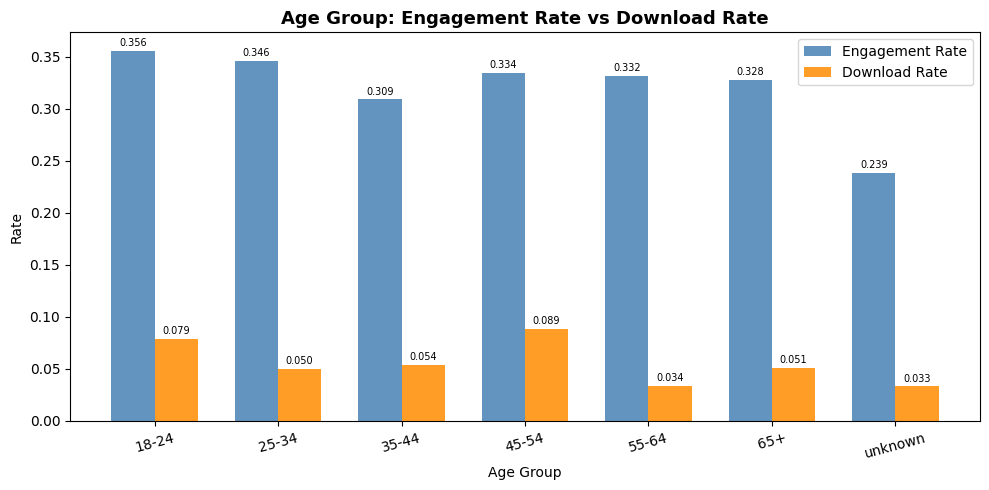

In [93]:
# Age — Grouped Bar (Engagement + Download Rate)
import matplotlib.pyplot as plt
import numpy as np

age_order = sorted(age_df['age'].unique())
age_plot = age_df.set_index('age').reindex(age_order).reset_index()

x = np.arange(len(age_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, age_plot['engagement_rate'], width, label='Engagement Rate', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, age_plot['download_rate'],  width, label='Download Rate',   color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(age_plot['age'], rotation=15)
ax.set_title('Age Group: Engagement Rate vs Download Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Rate')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', fontsize=7, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()


Younger audiences (18–34) show the highest engagement rates, but conversion to downloads varies. The 45–54 group exhibits the strongest download rate, indicating higher intent despite lower overall activity. This suggests that younger users engage more, while middle-aged users are more likely to take meaningful actions.

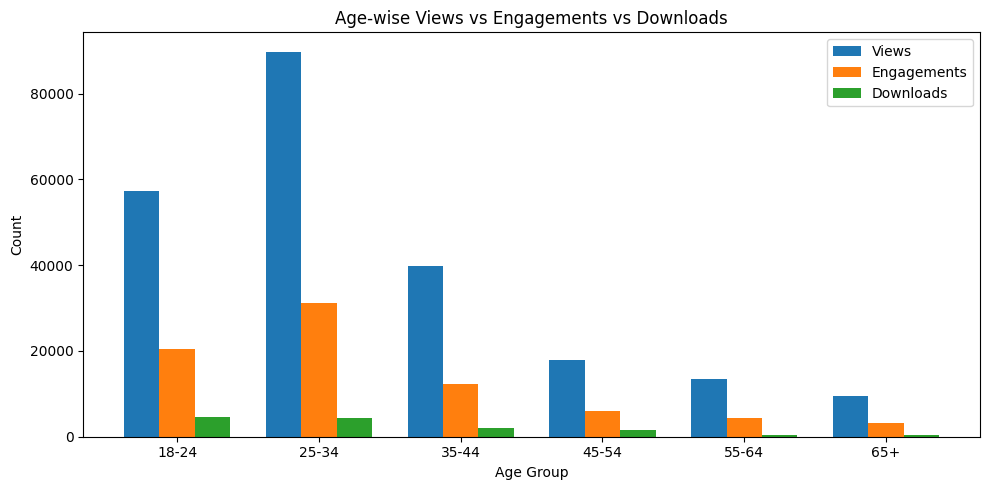

In [94]:
plot_df = age_df[age_df['age'] != 'unknown'].copy()

plot_df['age'] = pd.Categorical(plot_df['age'], categories=age_order, ordered=True)
plot_df = plot_df.sort_values('age')

x = np.arange(len(plot_df['age']))
width = 0.25  # smaller width for 3 bars

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, plot_df['views'], width, label='Views')
ax.bar(x, plot_df['engagements'], width, label='Engagements')
ax.bar(x + width, plot_df['downloads'], width, label='Downloads')

ax.set_title('Age-wise Views vs Engagements vs Downloads')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['age'])
ax.legend()

plt.tight_layout()
plt.show()

### Platform Source Analysis

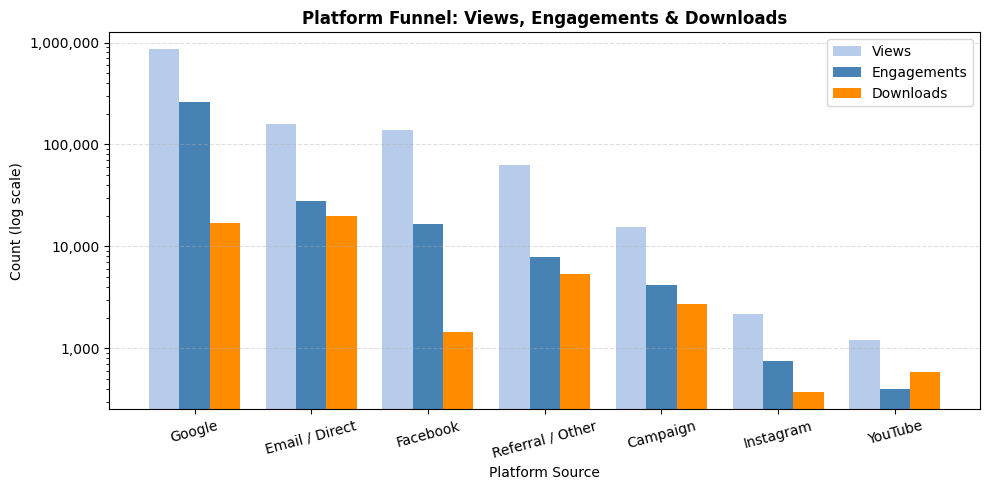

In [95]:
# Platform -- Funnel (Absolute Counts)
import matplotlib.pyplot as plt
import numpy as np

pg_funnel = platform_grouped.sort_values('views', ascending=False).copy()

x = np.arange(len(pg_funnel))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, pg_funnel['views'],       width, label='Views',       color='#aec7e8', alpha=0.9)
ax.bar(x,         pg_funnel['engagements'], width, label='Engagements', color='steelblue')
ax.bar(x + width, pg_funnel['downloads'],   width, label='Downloads',   color='darkorange')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(pg_funnel['platform_group'], rotation=15)
ax.set_title('Platform Funnel: Views, Engagements & Downloads', fontsize=12, fontweight='bold')
ax.set_xlabel('Platform Source')
ax.set_ylabel('Count (log scale)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda v, _: f'{int(v):,}' if v >= 1 else f'{v:.2f}'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Google dominates in reach, engagement, and downloads, confirming organic search as the primary acquisition channel. Email / Direct traffic shows strong conversion efficiency, indicating high-intent users. In contrast, social platforms such as Facebook and Instagram generate engagement but show weaker conversion to downloads. Overall, intent-driven channels outperform social channels in driving meaningful user actions.

### Country Analysis

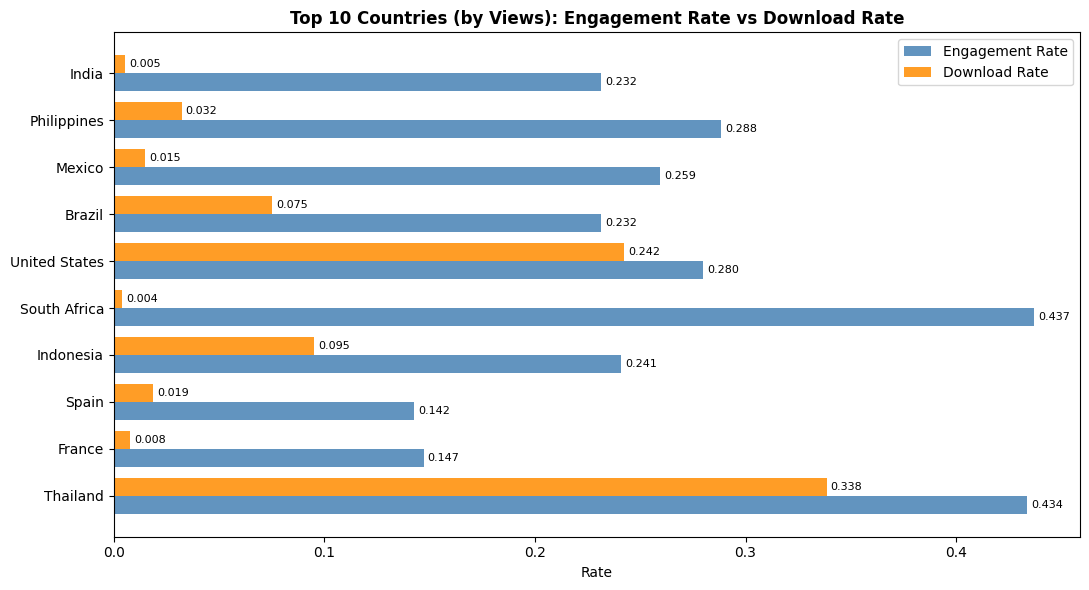

In [96]:
#Top 10 Countries -- Dual-Metric Horizontal Bar
import matplotlib.pyplot as plt
import numpy as np

top10 = country_df.nlargest(10, 'views').copy()
top10 = top10.sort_values('views', ascending=True)

x = np.arange(len(top10))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.barh(x - width/2, top10['engagement_rate'], width, label='Engagement Rate', color='steelblue', alpha=0.85)
bars2 = ax.barh(x + width/2, top10['download_rate'],  width, label='Download Rate',   color='darkorange', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(top10['country'])
ax.set_title('Top 10 Countries (by Views): Engagement Rate vs Download Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Rate')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()


Thailand and the United States demonstrate strong conversion performance, with high download rates relative to engagement. South Africa shows very high engagement but extremely low conversion, indicating a high-interest but low-intent audience. India and Mexico generate high traffic but comparatively low conversion efficiency, highlighting potential optimization opportunities.

### RQ2 Summary

**Research Question: How do audience demographics and geographic segments — including age group, country, and traffic source - vary in their engagement and download behavior on the Waste Hero website?**

Audience behavior varies significantly across demographic and geographic segments, revealing clear differences between high-traffic and high-intent users.

Age: Younger audiences (18-34) generate the highest engagement, but middle-aged groups (especially 45-54) show stronger download intent, indicating higher conversion efficiency despite lower activity levels.

Platform Source: Organic search (Google) drives the highest overall traffic and conversions, while Email / Direct channels demonstrate the strongest intent. In contrast, social platforms such as Facebook and Instagram generate engagement but convert less effectively into downloads.

Geography: Countries such as Thailand and the United States exhibit strong conversion performance, while regions like South Africa show high engagement but low download rates, indicating interest without action. High-traffic markets such as India and Mexico present opportunities for improving conversion efficiency.

Cross-Segment Insight: Across all dimensions, engagement does not directly translate into action. Conversion efficiency varies widely, with certain segments (e.g., YouTube, Email / Direct, and select geographic markets) demonstrating a stronger ability to convert engagement into downloads.

Final Conclusion: Audience effectiveness is not determined by reach alone. High-performing segments are those that efficiently convert engagement into meaningful actions, highlighting the importance of targeting high-intent users rather than high-volume audiences.